# Mode selection and truncation error

Parameters follow the D, sigma_k and x_tls conventions. The coupling profile is `sqrt`, as in Uri's experiments.
Numerical functions live in `experiment/`; this notebook controls their inputs and displays results.
See the [mathematical and code documentation](../documentation/main.pdf).


In [1]:
from pathlib import Path
import sys

# Works whether the kernel starts at the repository root or inside notebooks/.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'src' / 'xp_config.py').is_file() and (p / 'experiment').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from dataclasses import replace
import numpy as np
import pandas as pd
from IPython.display import display

# Keep small populations and norm drift visible; stored values retain full precision.
pd.set_option('display.float_format', '{:.9g}'.format)
import matplotlib.pyplot as plt
from src.xp_config import ExperimentConfig
from src.experiment import estimate_config
from src.fidelities import fidelities_over_time


## Parameters


In [2]:
CTRL_M_EXPLICIT = True
M = 5                         # Must be odd; k=0 is included.
cutoffs = {'ir_cutoff': 0.0, 'uv_cutoff': 2.0}  # Used only when control is False.

param_atom = {'omega_0': 1.0, 'D': 0.2, 'L': 2*np.pi,
              'x_tls': 0.0, 'coupling': 'sqrt', 'initial_state': 'g'}
param_photon = {'k_0': 1.0, 'sigma_k': 0.4, 'x_0': -2.0,
                'state': 'number', 'n': 1, 'alpha': 1.0}
param_time_evol = {'T': 4.0, 'dt': 0.05, 'rtol': 1e-9, 'atol': 1e-11}
n_max = 2
truncation = 'full+totalcap'
RWA = False

config = ExperimentConfig(param_photon, param_atom, param_time_evol, cutoffs,
                          n_max=n_max, truncation=truncation, RWA=RWA,
                          CTRL_M_EXPLICIT=CTRL_M_EXPLICIT, M=M)


## Resource estimates and simulation

The tables are stored as DataFrames. Memory estimates exclude sparse matrices, basis/Python objects, solver workspace and plots; `feasible` is a heuristic.


,L,delta_k,control,requested_M,requested_IR,requested_UV,n_modes,k_min,k_max,ir_effective,uv_effective,smallest_nonzero_k,zero_present,radial_cutoffs_exact,equivalent_M
grid,,,,,,,,,,,,,,,
base,6.28318531,1,explicit M,5,<NA>,<NA>,5,-2,2,0,2,1,True,True,5
selected,6.28318531,1,explicit M,5,<NA>,<NA>,5,-2,2,0,2,1,True,True,5


,basis,n_max,store_state,n_modes,dimension,n_times,ket_gib,history_gib,retained_vectors_gib,hamiltonian_nnz_bound,feasible
0,truncated,2,True,5,22,81,3.27825546e-07,2.65538692e-05,5.31077385e-05,242,True
1,full+totalcap,2,True,5,42,81,6.2584877e-07,5.06937504e-05,0.000101387501,462,True


,L,delta_k,control,requested_M,requested_IR,requested_UV,n_modes,k_min,k_max,ir_effective,uv_effective,smallest_nonzero_k,zero_present,radial_cutoffs_exact,equivalent_M
grid,,,,,,,,,,,,,,,
base,6.28318531,1,explicit M,5,<NA>,<NA>,5,-2,2,0,2,1,True,True,5
selected,6.28318531,1,explicit M,5,<NA>,<NA>,2,-1,1,1,1,1,False,True,<NA>


,basis,n_max,store_state,n_modes,dimension,n_times,ket_gib,history_gib,retained_vectors_gib,hamiltonian_nnz_bound,feasible
0,full+totalcap,2,True,2,12,81,1.78813934e-07,1.44839287e-05,2.89678574e-05,60,True


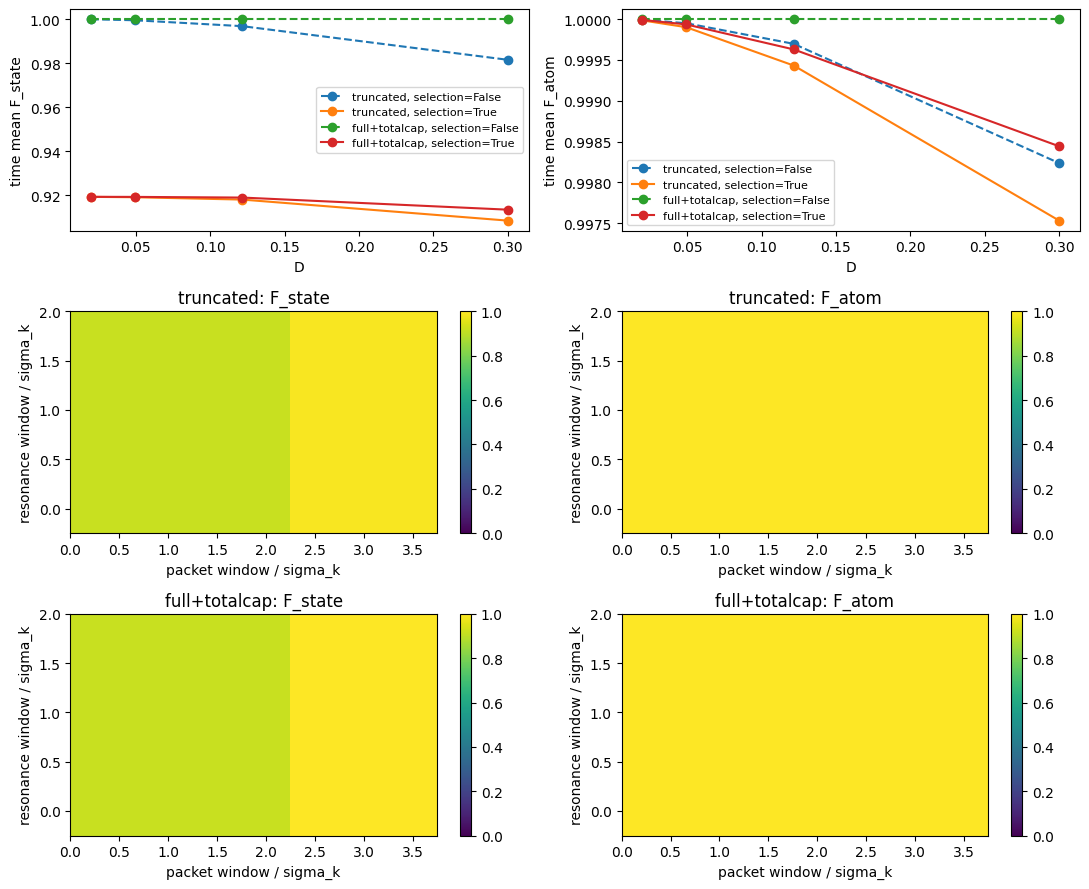

In [3]:
from experiment.compare_mode_selection import run_mode_selection, plot_mode_selection
D_values = np.geomspace(0.02, 0.3, 4)
schemes = ('truncated', 'full+totalcap')
photon_windows = (0.5, 1.5, 3.0)
atom_windows = (0.0, 0.5, 1.5)
# The base estimate bounds any selected grid for these same caps and output times.
checks = [estimate_config(replace(config, truncation=s), print_report=False) for s in schemes]
grid_table = checks[0]['grid_table']
resource_table = pd.concat([check['resource_table'] for check in checks], ignore_index=True)
display(grid_table, resource_table)
if not all(check['feasible'] for check in checks):
    raise MemoryError('Adjust the parameters after reviewing the resource estimates.')
selection_estimate = estimate_config(replace(config, mode_selection=True), print_report=False)
selected_grid_table = selection_estimate['grid_table']
selected_resource_table = selection_estimate['resource_table']
display(selected_grid_table, selected_resource_table)
results = run_mode_selection(config, D_values, schemes, photon_windows, atom_windows)
fig = plot_mode_selection(results)
plt.show()


## Additional diagnostics


In [4]:
fidelity_table = pd.DataFrame({
    f'{name}_{stage}': (results[f'{name}_initial'] if stage == 'initial' else results[name]).ravel()
    for name in ('F_state', 'F_atom') for stage in ('initial', 'time_mean')
}, index=pd.MultiIndex.from_product([results['schemes'], results['selection'], results['D']], names=['scheme', 'selection', 'D']))
display(fidelity_table)

window_table = pd.DataFrame({
    f'{name}_time_mean': results[f'{name}_heatmap'].ravel()
    for name in ('F_state', 'F_atom')
}, index=pd.MultiIndex.from_product(
    [results['schemes'], results['photon_windows'], results['atom_windows']],
    names=['scheme', 'photon_window', 'atom_window']))
window_table.attrs['D'] = results['D_heatmap']
display(window_table)


F_state_initial  ...  F_atom_time_mean
scheme        selection D                              ...                  
truncated     False     0.02                        1  ...       0.999991709
                        0.0493242415                1  ...       0.999949663
                        0.12164404                  1  ...       0.999696938
                        0.3                         1  ...       0.998236522
              True      0.02               0.91922449  ...        0.99998359
                        0.0493242415       0.91922449  ...       0.999901102
                        0.12164404         0.91922449  ...       0.999431109
                        0.3                0.91922449  ...       0.997532839
full+totalcap False     0.02                        1  ...                 1
                        0.0493242415                1  ...                 1
                        0.12164404                  1  ...                 1
                        0.3                         1  ...                 1
              True      0.02               0.91922449  ...       0.999989227
                        0.0493242415       0.91922449  ...       0.999935125
                        0.12164404         0.91922449  ...       0.999628603
                        0.3                0.91922449  ...       0.998442735

[16 rows x 4 columns]

F_state_time_mean  F_atom_time_mean
scheme        photon_window atom_window                                     
truncated     0.5           0                   0.91531783       0.998627982
                            0.5                 0.91531783       0.998627982
                            1.5                 0.91531783       0.998627982
              1.5           0                   0.91531783       0.998627982
                            0.5                 0.91531783       0.998627982
                            1.5                 0.91531783       0.998627982
              3             0                  0.990955644       0.999247508
                            0.5                0.990955644       0.999247508
                            1.5                0.990955644       0.999247508
full+totalcap 0.5           0                  0.917704238       0.999113708
                            0.5                0.917704238       0.999113708
                            1.5                0.917704238       0.999113708
              1.5           0                  0.917704238       0.999113708
                            0.5                0.917704238       0.999113708
                            1.5                0.917704238       0.999113708
              3             0                  0.996640413       0.999929671
                            0.5                0.996640413       0.999929671
                            1.5                0.996640413       0.999929671